# Agent Pattern Examples with LangGOAP

Five canonical agent workflow patterns rendered in LangGOAP. Each example
shows how to translate a common LLM agent pattern into declarative
preconditions and effects so the A\* planner can assemble the workflow
automatically.

## Examples

1. **Star News Finder** — Multi-step LLM pipeline with web search
2. **Meal Preparation** — Parallel preconditions merging at a goal action
3. **Write and Review** — Iterative refinement via replanning
4. **Fact Checker** — Multi-step verification pipeline
5. **Cost-Based Planning** — A\* prefers cheap actions over expensive ones

In [1]:
from typing import Any

from langchain_openai import ChatOpenAI

from langgoap import ActionSpec, GoalSpec, GoapGraph, ReplanStrategy
from tutorial_examples.agent_pattern_examples import (
    fact_checker_actions,
    meal_prep_actions,
    star_news_actions,
    write_review_actions,
)

# Requires OPENAI_API_KEY environment variable
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

### GOAP Execution Graph

The planner discovers a plan, the executor runs each action, and the
observer checks progress — replanning automatically if something fails.

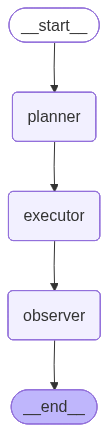

In [2]:
from IPython.display import Image, display

graph = GoapGraph(actions=star_news_actions(llm))
display(Image(graph.compile().get_graph().draw_mermaid_png()))

---

## 1. Star News Finder

A multi-step LLM pipeline chains five actions:

```
extract_person(user_input)         → person
extract_star_sign(person)          → star_person
retrieve_horoscope(star_person)    → horoscope
find_news_stories(star_person,
                  horoscope)       → relevant_news
star_news_writeup(star_person,
                  horoscope, news) → writeup  (goal)
```

In LangGOAP, the A\* planner discovers this sequence from preconditions/effects.

In [3]:
star_actions = star_news_actions(llm)

In [4]:
result = GoapGraph(actions=star_actions).invoke(
    goal=GoalSpec(conditions={"writeup_complete": True}),
    world_state={"has_user_input": True, "user_input": "Tell me about Alice who is an Aries"},
)

print(f"Status: {result['status']}")
print(f"Writeup: {result['world_state']['writeup'][:300]}...")
print()
successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Pipeline: {' -> '.join(successful)}")

Status: goal_achieved
Writeup: **Aries Star Alice Shines Bright!** Today, the fiery Aries influencer Alice is riding a wave of technological fortune, launching a new charity initiative aimed at supporting local artists. Not only is she making waves in the philanthropic world, but her latest fashion collaboration is breaking recor...

Pipeline: extract_person -> extract_star_sign -> retrieve_horoscope -> find_news_stories -> star_news_writeup


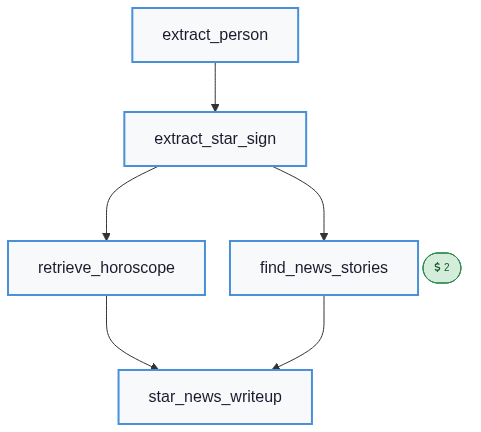

In [5]:
display(Image(result["plan"].draw_mermaid_png()))

### Partial Goal: Horoscope Only

The planner stops at `retrieve_horoscope` — no news search or writeup needed.

In [6]:
result = GoapGraph(actions=star_actions).invoke(
    goal=GoalSpec(conditions={"has_horoscope": True}),
    world_state={"has_user_input": True},
)

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Actions: {successful}")
print(f"Writeup skipped: {'star_news_writeup' not in successful}")

Actions: ['extract_person', 'extract_star_sign', 'retrieve_horoscope']
Writeup skipped: True


---

## 2. Meal Preparation

Classic GOAP pattern: two independent precondition paths merge at the final action.

```
chooseCook(UserInput)  → Cook
takeOrder(UserInput)   → Order
prepareMeal(Cook, Order) → Meal  @AchievesGoal
```

Both `choose_cook` and `take_order` share the same precondition but produce
different effects. `prepare_meal` requires both.

In [7]:
meal_actions = meal_prep_actions(llm)

In [8]:
result = GoapGraph(actions=meal_actions).invoke(
    goal=GoalSpec(conditions={"meal_ready": True}),
    world_state={"has_user_input": True},
)

print(f"Status: {result['status']}")
ws = result["world_state"]
print(f"Cook: {ws.get('cook', 'N/A')}")
print(f"Order: {ws.get('order', 'N/A')}")
print(f"Meal: {str(ws.get('meal', 'N/A'))[:200]}...")

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Actions: {successful}")
print(f"prepare_meal after choose_cook: {successful.index('prepare_meal') > successful.index('choose_cook')}")
print(f"prepare_meal after take_order: {successful.index('prepare_meal') > successful.index('take_order')}")

Status: goal_achieved
Cook: {'name': '"Chef Antonio",', 'specialty': '"Italian cuisine"'}
Order: {'dish': "Chef's special", 'special_requests': 'none'}
Meal: {'dish': "Chef's special", 'prepared_by': '"Chef Antonio",', 'quality': 'excellent', 'description': "Chef Antonio meticulously gathers fresh ingredients from his well-stocked pantry, expertly chopping...
Actions: ['choose_cook', 'take_order', 'prepare_meal']
prepare_meal after choose_cook: True
prepare_meal after take_order: True


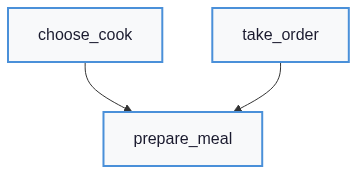

In [9]:
display(Image(result["plan"].draw_mermaid_png()))

### Partial Prerequisites

When the cook is already chosen, only `take_order → prepare_meal` are needed.

In [10]:
result = GoapGraph(actions=meal_actions).invoke(
    goal=GoalSpec(conditions={"meal_ready": True}),
    world_state={
        "has_user_input": True,
        "has_cook": True,
        "cook": {"name": "Chef Pierre", "specialty": "Italian cuisine"},
    },
)

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Actions: {successful}")
print(f"choose_cook skipped: {'choose_cook' not in successful}")

Actions: ['take_order', 'prepare_meal']
choose_cook skipped: True


### Goal Already Satisfied

When the meal is already ready, no actions are needed.

In [11]:
result = GoapGraph(actions=meal_actions).invoke(
    goal=GoalSpec(conditions={"meal_ready": True}),
    world_state={"meal_ready": True},
)

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Status: {result['status']}")
print(f"Actions executed: {len(successful)}")

Status: goal_achieved
Actions executed: 0


---

## 3. Write and Review

Iterative refinement via assess/revise loops:

```
craft_story(user_input)     → story
assess_story(story)         → assessment (accept/reject)
If rejected: revise_story(story, feedback) → story (loop back)
If accepted: finalize_review(story)        → reviewed_story  (goal)
```

In LangGOAP, each phase is a separate action with honest declared effects.
The `assess_story` action writes to a distinct key (`story_approved`) —
it never undoes `has_story`.  On rejection it also sets `needs_revision=True`,
which enables the `revise_story` action.  A\* selects `revise_story` over
re-running `assess_story` via specificity tie-breaking (more preconditions
satisfied = preferred).

In [12]:
review_actions = write_review_actions(llm)

result = GoapGraph(actions=review_actions).invoke(
    goal=GoalSpec(conditions={"review_complete": True}),
    world_state={"has_user_input": True, "user_input": "a brave astronaut explored Mars"},
)

print(f"Status: {result['status']}")
ws = result["world_state"]
print(f"Story (first 200 chars): {ws['story'][:200]}...")
print(f"Review: {str(ws.get('reviewed_story', 'N/A'))[:200]}...")
successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Pipeline: {' -> '.join(successful)}")

Status: goal_achieved
Story (first 200 chars): Captain Elara Voss stood on the crimson surface of Mars, her heart racing with a mix of fear and exhilaration. As she took her first step, the dust swirled around her like a thousand whispers, urging ...
Review: {'story': 'Captain Elara Voss stood on the crimson surface of Mars, her heart racing with a mix of fear and exhilaration. As she took her first step, the dust swirled around her like a thousand whispe...
Pipeline: craft_story -> assess_story -> finalize_review


### Revision via Replanning

When `assess_story` rejects the story, it returns `story_approved=False`
(deviating from the declared `True`) and sets `needs_revision=True`.
The observer triggers replanning.  In the new state, `revise_story` is
preferred over `assess_story` via A\* specificity tie-breaking (2 preconditions
vs 1).  `revise_story` rewrites the story and produces `story_approved=True`,
after which `finalize_review` completes the goal.

Note that `has_story` is never undone — each action only writes to its own
declared keys.

In [13]:
# Strict assessment + revision loop via LLM
revision_actions = write_review_actions(llm, strict=True, include_revise=True)

result = GoapGraph(actions=revision_actions).invoke(
    goal=GoalSpec(
        conditions={"review_complete": True},
        replan_strategy=ReplanStrategy.ON_DEVIATION,
    ),
    world_state={"has_user_input": True, "user_input": "dragons and knights"},
)

print(f"Status: {result['status']}")
print(f"Replans: {result['replan_count']}")
print(f"Final story (first 200 chars): {result['world_state']['story'][:200]}...")
print(f"has_story preserved: {result['world_state']['has_story']}")
successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Actions: {successful}")

Status: goal_achieved
Replans: 1
Final story (first 200 chars): [REVISED] 

In a kingdom where dragons glided through the skies like whispers of forgotten legends, a courageous knight named Elara stood at the forefront of a long-standing conflict. For generations,...
has_story preserved: True
Actions: ['craft_story', 'assess_story', 'revise_story', 'finalize_review']


---

## 4. Fact Checker

Chain extraction → rationalization → verification:

```
extract_assertions(content)                 → factual_assertions
rationalize_assertions(factual_assertions)  → rationalized_assertions
check_facts(rationalized_assertions)        → fact_check  (goal)
```

In [14]:
fact_check_actions = fact_checker_actions(llm)

In [15]:
result = GoapGraph(actions=fact_check_actions).invoke(
    goal=GoalSpec(conditions={"fact_check_complete": True}),
    world_state={
        "has_content": True,
        "content": "Python was created by Guido van Rossum in 1991. "
        "LangChain was released in 2022 for LLM app development.",
    },
)

ws = result["world_state"]
print(f"Status: {result['status']}")
print(f"Fact check result: {str(ws.get('fact_check', 'N/A'))[:400]}...")

successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"\nPipeline: {' → '.join(successful)}")

Status: goal_achieved
Fact check result: {'total_claims': 4, 'verified': 4, 'checks': [{'claim': 'Python was created by Guido van Rossum.', 'verified': True, 'confidence': 0.95}, {'claim': 'Python was created in 1991.', 'verified': True, 'confidence': 0.95}, {'claim': 'LangChain was released in 2022.', 'verified': True, 'confidence': 0.95}, {'claim': 'LangChain is used for LLM app development.', 'verified': True, 'confidence': 0.95}]}...

Pipeline: extract_assertions → rationalize_assertions → check_facts


---

## 5. Cost-Based Planning

Mark expensive actions with a high ``cost`` to push them to last resort.
LangGOAP's A\* planner minimizes total path cost, so cheap actions are
always preferred when both satisfy the goal.

In [16]:
def cache_lookup(ws: dict[str, Any]) -> dict[str, Any]:
    return {"has_answer": True, "answer": "cached result", "source": "cache"}


def api_call(ws: dict[str, Any]) -> dict[str, Any]:
    return {"has_answer": True, "answer": "api result", "source": "api"}


cost_actions = [
    ActionSpec(
        name="cache_lookup",
        preconditions={"has_query": True},
        effects={"has_answer": True},
        cost=1.0,  # Cheap
        execute=cache_lookup,
    ),
    ActionSpec(
        name="api_call",
        preconditions={"has_query": True},
        effects={"has_answer": True},
        cost=100.0,  # Expensive: high cost marks as last resort
        execute=api_call,
    ),
]

result = GoapGraph(actions=cost_actions).invoke(
    goal=GoalSpec(conditions={"has_answer": True}),
    world_state={"has_query": True, "query": "What is GOAP?"},
)

ws = result["world_state"]
print(f"Source: {ws['source']} (cache preferred over API)")
successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Action used: {successful[0]}")

Source: cache (cache preferred over API)
Action used: cache_lookup


### Multi-Step Cost Optimization

A\* optimizes total path cost across multiple steps.

In [17]:
def fast_extract(ws: dict[str, Any]) -> dict[str, Any]:
    return {"has_data": True, "data": "fast"}


def thorough_extract(ws: dict[str, Any]) -> dict[str, Any]:
    return {"has_data": True, "data": "thorough"}


def process(ws: dict[str, Any]) -> dict[str, Any]:
    return {"processed": True, "result": f"processed {ws.get('data', '')}"}


multi_cost_actions = [
    ActionSpec(name="fast_extract", preconditions={"has_input": True}, effects={"has_data": True}, cost=1.0, execute=fast_extract),
    ActionSpec(name="thorough_extract", preconditions={"has_input": True}, effects={"has_data": True}, cost=10.0, execute=thorough_extract),
    ActionSpec(name="process", preconditions={"has_data": True}, effects={"processed": True}, cost=1.0, execute=process),
]

result = GoapGraph(actions=multi_cost_actions).invoke(
    goal=GoalSpec(conditions={"processed": True}),
    world_state={"has_input": True},
)

print(f"Result: {result['world_state']['result']}")
print(f"Path: fast_extract(1) + process(1) = 2  vs  thorough_extract(10) + process(1) = 11")
successful = [h.action_name for h in result["execution_history"] if h.success]
print(f"Chosen path: {' → '.join(successful)}")

Result: processed fast
Path: fast_extract(1) + process(1) = 2  vs  thorough_extract(10) + process(1) = 11
Chosen path: fast_extract → process
